In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

import matplotlib.pyplot as pltK

In [18]:
dataset_path = Path("../data/CHEST X RAY")
train_path = dataset_path / "train"
test_path = dataset_path / "test"

print(train_path)
print(test_path)

..\data\CHEST X RAY\train
..\data\CHEST X RAY\test


In [19]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [22]:
# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 4246 files belonging to 2 classes.
Using 3397 files for training.


In [23]:
# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 4246 files belonging to 2 classes.
Using 849 files for validation.


In [24]:
# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1622 files belonging to 2 classes.


In [25]:
# Class Names
class_names = train_ds.class_names

print(class_names)

['NORMAL', 'PNEUMONIA']


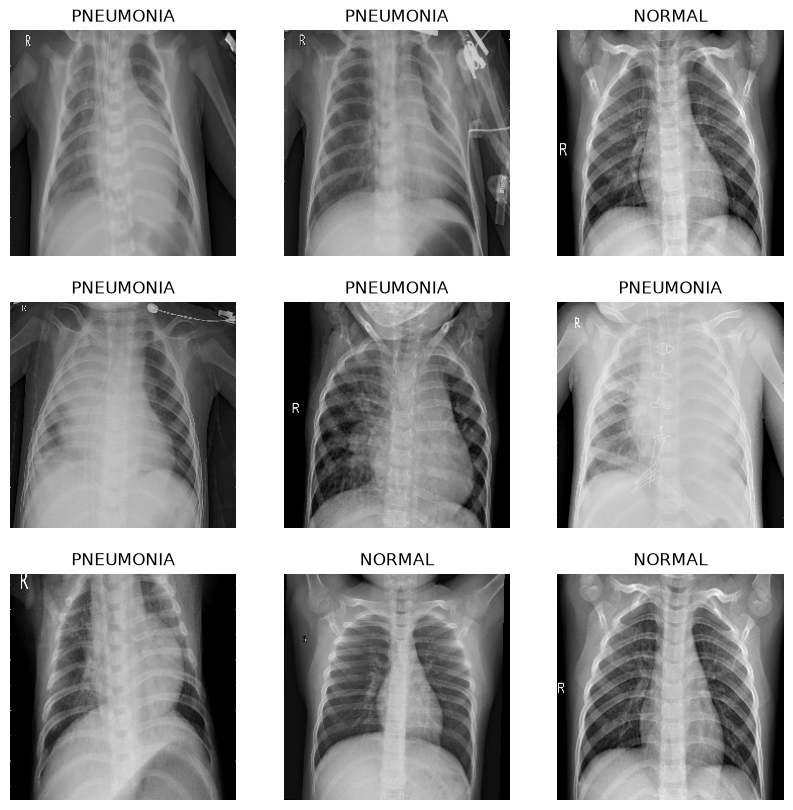

In [28]:
# Visualize Training Images
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

## Performance Optimization

In [29]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

## Data Augmentation

In [31]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Test Augmentation

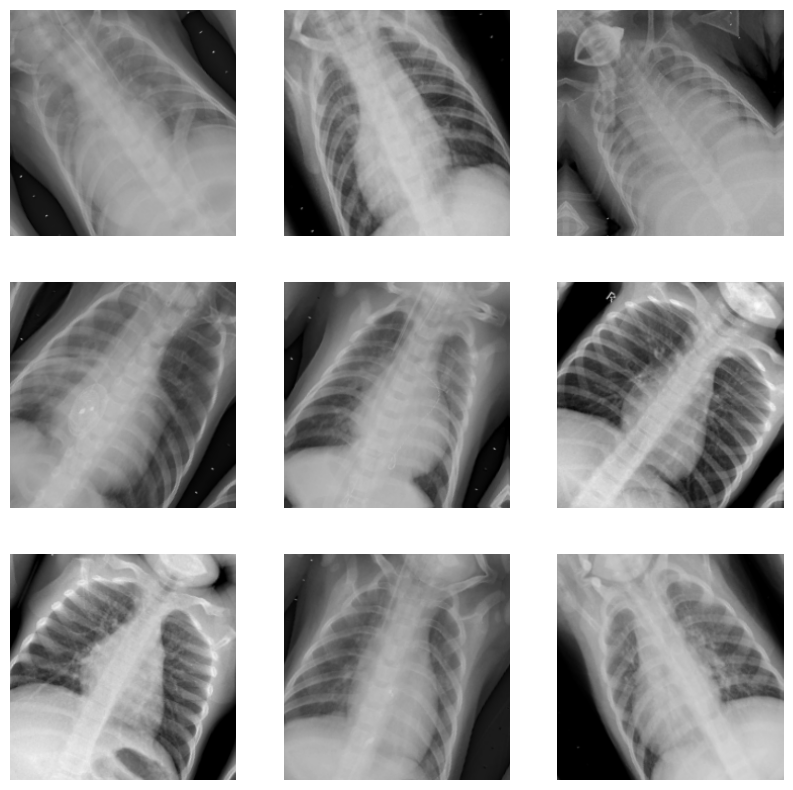

In [32]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

## Check Dataset Shapesm

In [33]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
